In [25]:
import pandas as pd
df = pd.read_csv('llm_benchmark_leaderboard_2024_2026.csv')

In [26]:
df.head()

,model_name,provider,release_date,model_family,parameter_count_B,open_weights,license,context_window_tokens,max_output_tokens,supports_vision,...,training_data_cutoff,hq_country,modality,api_available,free_tier_available,days_since_release,is_free,cost_per_1M_combined,price_tier,arena_rank
0,Gemini 2.5 Pro,Google DeepMind,2025-03-25,Gemini 2.5,NaN,False,Proprietary,1000000,65536,True,...,2025-01,United States,Text + Vision + Audio + Video,True,True,340,False,11.25,Mid-Range,1
1,Grok-3,xAI,2025-02-17,Grok,NaN,False,Proprietary,128000,128000,True,...,2024-10,United States,Text + Vision,True,True,376,False,18.00,Mid-Range,2
2,Claude Sonnet 4,Anthropic,2025-05-22,Claude 4,NaN,False,Proprietary,200000,16384,True,...,2025-03,United States,Text + Vision,True,True,282,False,18.00,Mid-Range,3
3,DeepSeek-R1,DeepSeek,2025-01-20,DeepSeek-R1,671.0,True,MIT,128000,128000,False,...,2024-08,China,Text,True,True,404,False,2.74,Budget,4
4,Gemini 2.0 Flash,Google DeepMind,2025-02-05,Gemini 2.0,NaN,False,Proprietary,1000000,8192,True,...,2024-08,United States,Text + Vision + Audio + Video,True,True,388,False,0.50,Ultra-Low,5


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   model_name                  40 non-null     object 
 1   provider                    40 non-null     object 
 2   release_date                40 non-null     object 
 3   model_family                40 non-null     object 
 4   parameter_count_B           20 non-null     float64
 5   open_weights                40 non-null     bool   
 6   license                     40 non-null     object 
 7   context_window_tokens       40 non-null     int64  
 8   max_output_tokens           40 non-null     int64  
 9   supports_vision             40 non-null     bool   
 10  supports_audio              40 non-null     bool   
 11  supports_tool_use           40 non-null     bool   
 12  input_price_per_1M_tokens   40 non-null     float64
 13  output_price_per_1M_tokens  40 non-nu

In [28]:
df.describe()

,parameter_count_B,context_window_tokens,max_output_tokens,input_price_per_1M_tokens,output_price_per_1M_tokens,arena_elo_score,mmlu_score,humaneval_score,gpqa_diamond_score,math_score,days_since_release,cost_per_1M_combined,arena_rank
count,20.000000,4.000000e+01,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,35.000000,40.000000,40.000000,40.000000,40.000000
mean,186.385000,2.664328e+05,74720.200000,2.023625,8.512250,1261.775000,83.020000,81.890000,54.202857,69.075000,533.375000,10.535875,20.500000
std,215.119126,3.909803e+05,159351.267112,3.530040,15.343896,74.258208,6.317789,12.059272,15.239335,20.453183,133.980421,18.802602,11.690452
min,8.000000,4.096000e+03,4096.000000,0.000000,0.000000,1106.000000,69.400000,40.200000,28.100000,28.400000,282.000000,0.000000,1.000000
25%,30.750000,1.280000e+05,8192.000000,0.000000,0.000000,1215.500000,78.775000,74.025000,42.800000,54.150000,423.500000,0.000000,10.750000
50%,88.000000,1.280000e+05,16384.000000,0.800000,3.100000,1260.500000,84.650000,86.050000,52.300000,72.100000,559.500000,4.400000,20.500000
75%,354.500000,2.000000e+05,128000.000000,2.625000,10.000000,1307.000000,87.750000,90.650000,65.000000,84.175000,631.750000,12.500000,30.250000
max,671.000000,2.000000e+06,1000000.000000,15.000000,75.000000,1439.000000,92.000000,95.000000,84.000000,98.600000,782.000000,90.000000,40.000000


gpqa_diamond_score — это бенчмарк (Google-Proof Q&A), в котором собраны вопросы по физике, биологии и химии на уровне аспирантуры. "Google-Proof"

у нас 20 пропусков в parameter_count_B и 5 пропусков в gpqa_diamond_score.

Если мы просто в лоб удалим все строки с NaN, то потеряем ровно половину датасета, включая почти все закрытые модели от OpenAI и Anthropic (они просто не раскрывают количество параметров).

Вместо банального удаления строк с NaN, которое привело бы к потере 12.5% выборки, была применена импутация данных на основе коррелирующих метрик

In [29]:
df.shape

(40, 30)

In [30]:
df['parameter_count_B'] = df['parameter_count_B'].fillna(0)

mean_ratio= (df['gpqa_diamond_score'] / df['mmlu_score']).mean()
df.loc[df['gpqa_diamond_score'].isna(), 'gpqa_diamond_score'] = df['mmlu_score'] * mean_ratio

df['release_date']= pd.to_datetime(df['release_date'])
df['release_year'] = df['release_date'].dt.year

df['cost_per_1M_combined'] =df['cost_per_1M_combined'].replace(0, 0.0001)
df['value_for_money']= df['mmlu_score'] / df['cost_per_1M_combined']

print(df.isna().sum())

model_name                    0
provider                      0
release_date                  0
model_family                  0
parameter_count_B             0
open_weights                  0
license                       0
context_window_tokens         0
max_output_tokens             0
supports_vision               0
supports_audio                0
supports_tool_use             0
input_price_per_1M_tokens     0
output_price_per_1M_tokens    0
arena_elo_score               0
mmlu_score                    0
humaneval_score               0
gpqa_diamond_score            0
math_score                    0
coding_benchmark              0
training_data_cutoff          0
hq_country                    0
modality                      0
api_available                 0
free_tier_available           0
days_since_release            0
is_free                       0
cost_per_1M_combined          0
price_tier                    0
arena_rank                    0
release_year                  0
value_fo

In [31]:
df.shape

(40, 32)

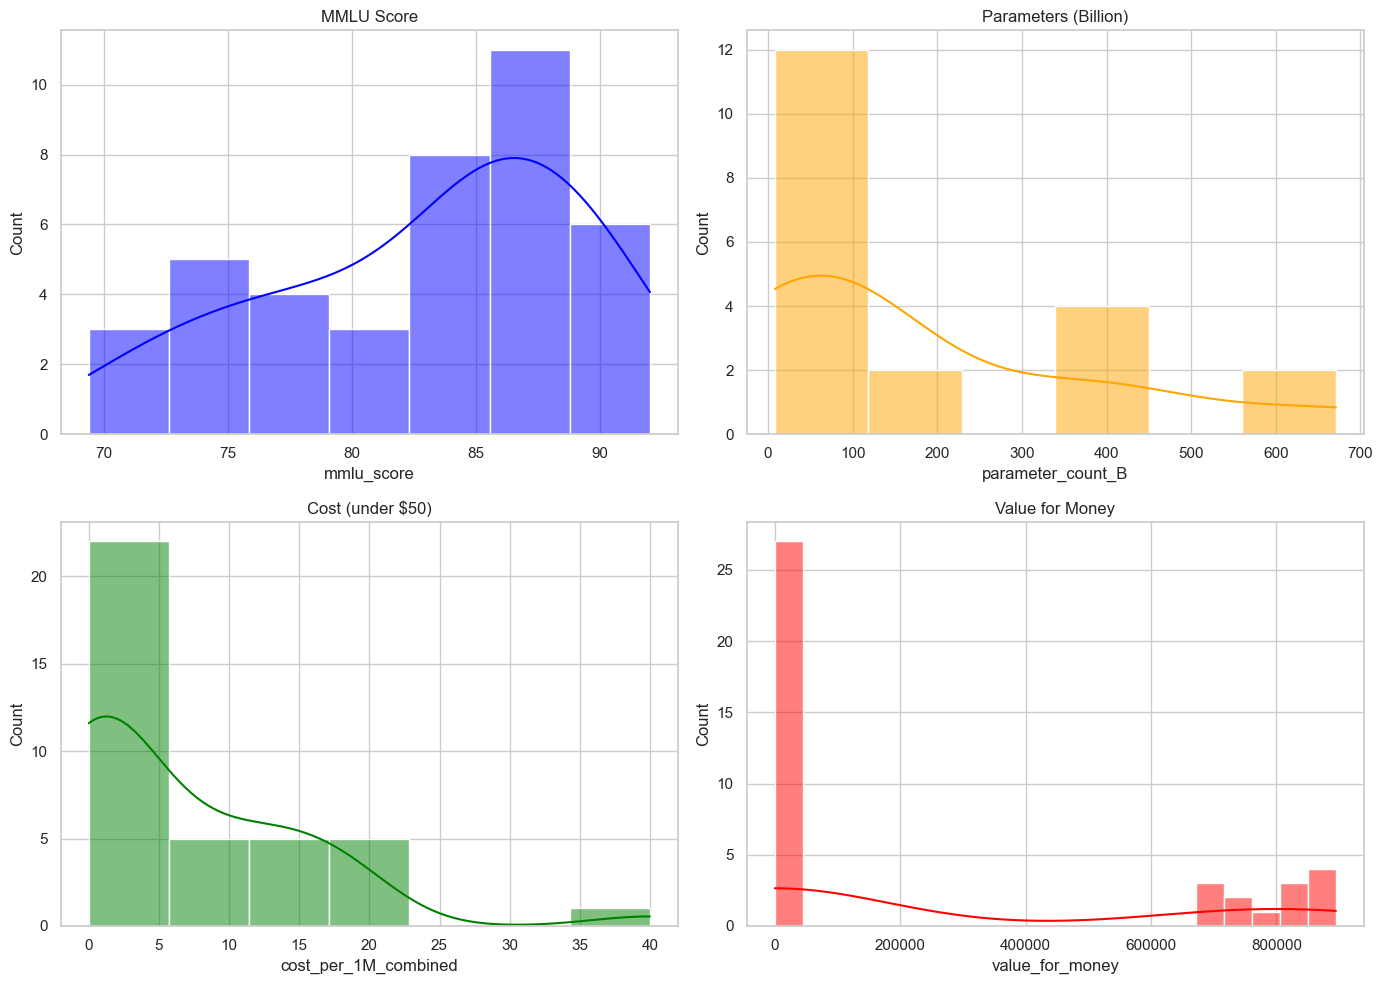

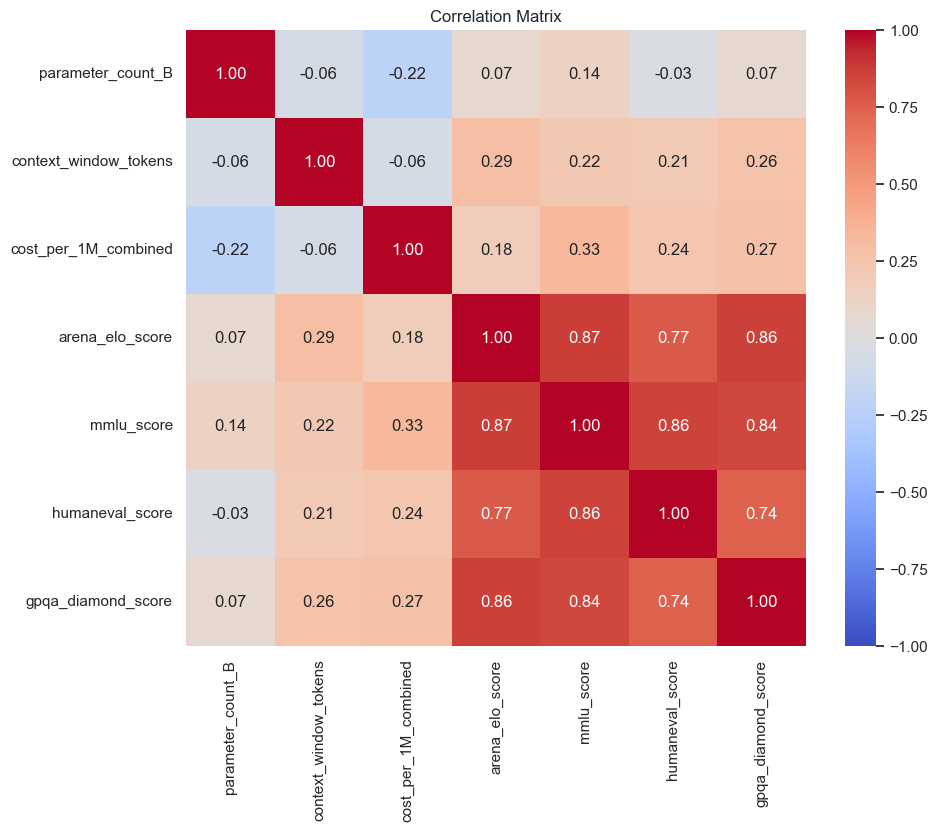

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(data=df, x='mmlu_score', kde=True, ax=axes[0, 0], color='blue')
axes[0, 0].set_title('MMLU Score')

sns.histplot(data=df[df['parameter_count_B'] > 0], x='parameter_count_B', kde=True, ax=axes[0, 1], color='orange')
axes[0, 1].set_title('Parameters (Billion)')

sns.histplot(data=df[df['cost_per_1M_combined'] < 50], x='cost_per_1M_combined', kde=True, ax=axes[1, 0], color='green')
axes[1, 0].set_title('Cost (under $50)')

sns.histplot(data=df, x='value_for_money', kde=True, bins=20, ax=axes[1, 1], color='red')
axes[1, 1].set_title('Value for Money')

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
numeric_cols = ['parameter_count_B', 'context_window_tokens', 'cost_per_1M_combined',
                'arena_elo_score', 'mmlu_score', 'humaneval_score', 'gpqa_diamond_score']
corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

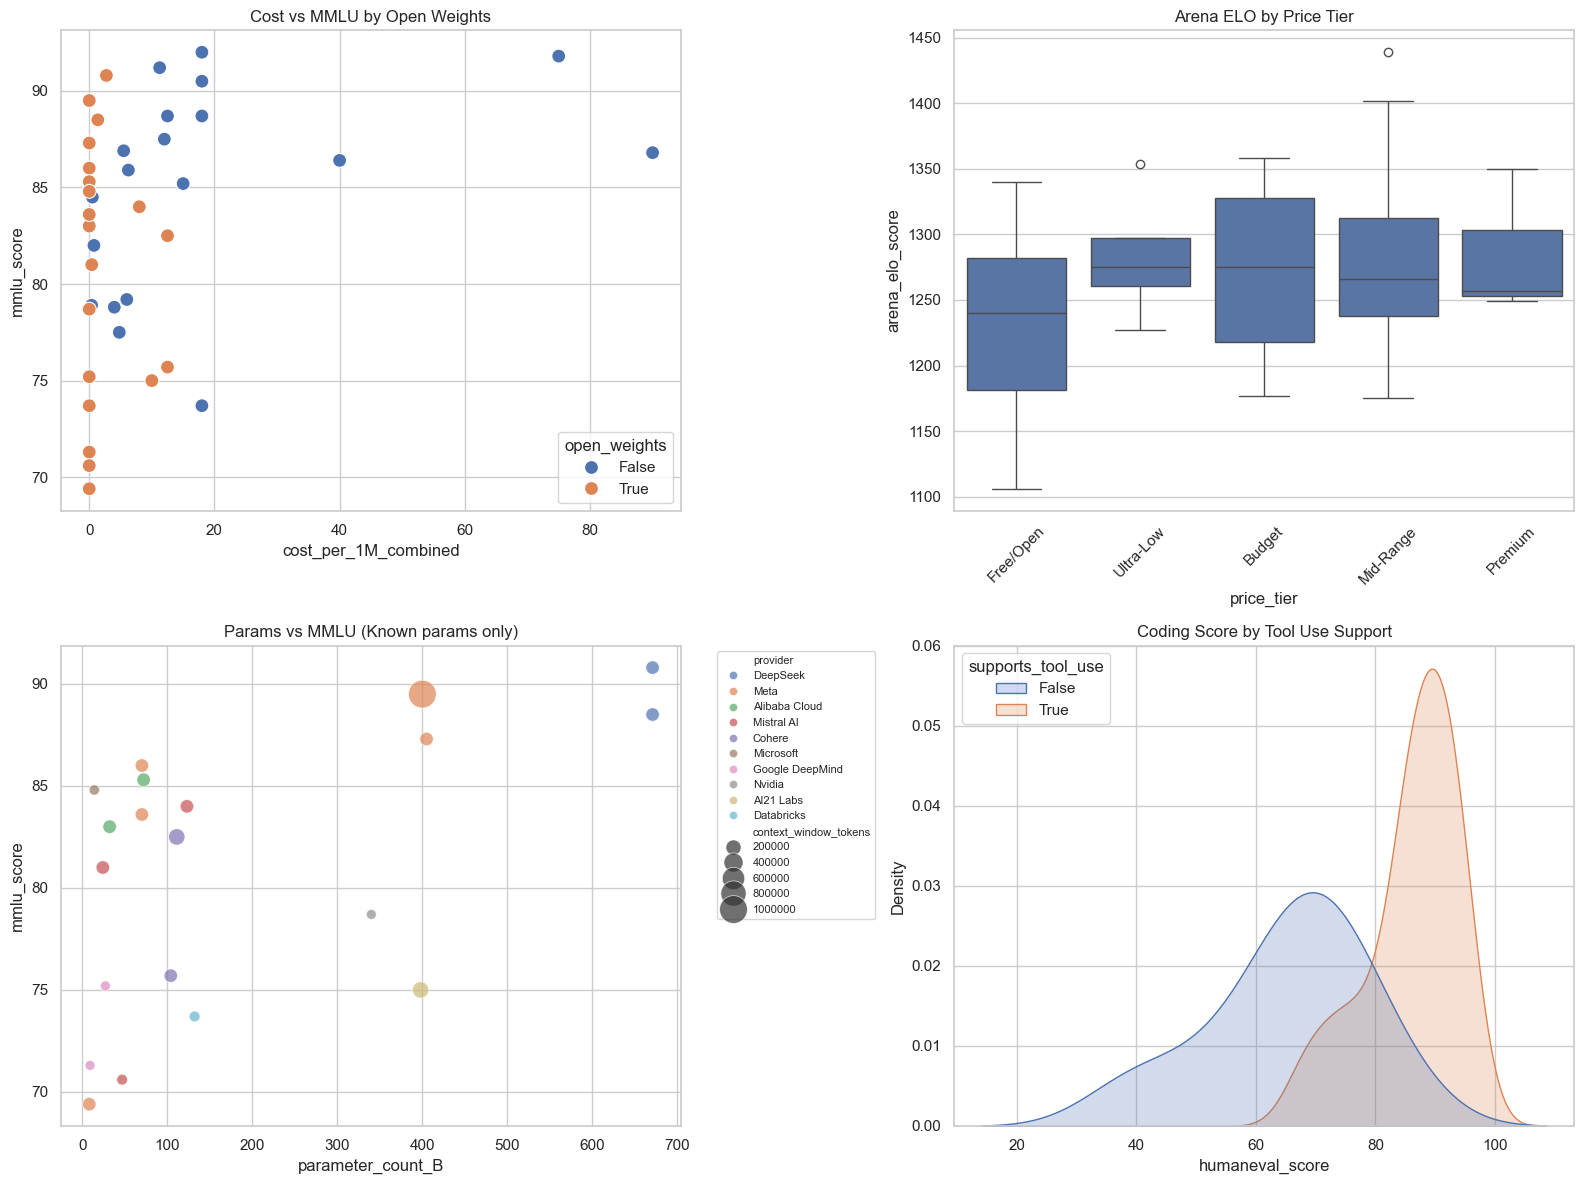

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

fig,axes=plt.subplots(2,2, figsize=(16, 12))

sns.scatterplot(data=df, x='cost_per_1M_combined', y='mmlu_score', hue='open_weights', s=100, ax=axes[0,0])
axes[0,0].set_title('Cost vs MMLU by Open Weights')

sns.boxplot(data=df, x='price_tier', y='arena_elo_score', ax=axes[0,1], order=['Free/Open', 'Ultra-Low', 'Budget', 'Mid-Range', 'Premium'])
axes[0,1].set_title('Arena ELO by Price Tier')
axes[0,1].tick_params(axis='x', rotation=45)

df_params = df[df['parameter_count_B']>0]
sns.scatterplot(data=df_params, x='parameter_count_B', y='mmlu_score', size='context_window_tokens', hue='provider', sizes=(50,400), ax=axes[1,0], alpha=0.7)
axes[1,0].set_title('Params vs MMLU (Known params only)')
axes[1,0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

sns.kdeplot(data=df, x='humaneval_score', hue='supports_tool_use', fill=True, common_norm=False, ax=axes[1,1])
axes[1,1].set_title('Coding Score by Tool Use Support')

plt.tight_layout()
plt.show()

Cost vs MMLU (верхний левый): Опенсорс (оранжевые точки) ожидаемо кучкуется на отметке $0, но при этом показывает разброс качества от 70 до почти 90 баллов. Закрытые модели (синие) размазаны по всему ценовому спектру, и тут есть забавный инсайт: самая дорогая модель — далеко не самая умная.

Arena ELO by Price Tier (верхний правый): Премиум-сегмент ожидаемо имеет высокую медиану и малый разброс (они стабильно хороши). А вот в Mid-Range и Budget мы видим огромные "усы" и точки-выбросы наверху — это значит, что в среднем сегменте появились модели, которые бьют премиум (привет, новые Gemini и DeepSeek).

Params vs MMLU (нижний левый): Тут четкий восходящий тренд. Чем больше параметров у открытой модели, тем она умнее. Огромные пузыри справа вверху — это гиганты на 400B+ параметров.

Coding Score by Tool Use (нижний правый): Пожалуй, самый наглядный график. Распределения почти не пересекаются. Модели, которые умеют использовать инструменты (оранжевые), пишут код кардинально лучше тех, кто этого не умеет.

In [34]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [35]:
import scipy.stats as stats
import statsmodels.api as sm

recent=df[df['days_since_release'] < 400]
open_m = recent[recent['open_weights']==True]['mmlu_score']
prop_m = recent[recent['open_weights'] ==False]['mmlu_score']

stat, pval= stats.ttest_ind(prop_m,open_m, equal_var=False)
print(pval)

X=df[['mmlu_score', 'cost_per_1M_combined']]
X=sm.add_constant(X)
Y= df['arena_elo_score']

model =sm.OLS(Y, X).fit()
print(model.summary())

0.07798743701332264
                            OLS Regression Results                            
Dep. Variable:        arena_elo_score   R-squared:                       0.772
Model:                            OLS   Adj. R-squared:                  0.760
Method:                 Least Squares   F-statistic:                     62.70
Date:                Tue, 09 Jun 2026   Prob (F-statistic):           1.30e-12
Time:                        15:31:09   Log-Likelihood:                -198.97
No. Observations:                  40   AIC:                             403.9
Df Residuals:                      37   BIC:                             409.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const       

In [36]:
df.to_csv('dataset.csv', index=False)